## EDA on Weather Data (WeatherWizard)
Public weather dataset from [Open-meteo API](https://open-meteo.com/)
- Collins Emezie Ugwuozor
- [LinkedIn](https://www.linkedin.com/in/collins-ugwuozor)

In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt
from datetime import datetime, date
from IPython.display import display, clear_output
from statsmodels.tsa.seasonal import seasonal_decompose
from ipywidgets import interact_manual, Text, DatePicker

from ml_model import fetch_weather_data

import warnings
warnings.filterwarnings("ignore")

In [2]:
# I selected three cities accros Africa for this study
cities = ["Lagos", "Nairobi", "Cairo"]
start_date = "2025-01-01"
end_date = "2025-05-20"

In [3]:
df_eda = fetch_weather_data(cities, start_date, end_date)

### Preview the data

In [4]:
df = df_eda.copy()

In [5]:
df_eda.shape

(10080, 11)

In [6]:
df_eda.head(3)

,Datetime,Temperature (°C),Humidity (%),Pressure (hPa),Wind Speed (m/s),Wind Direction (°),Wind Gusts (m/s),Precipitation (mm),Cloud Cover (%),Solar Radiation (W/m²),City
0,2025-01-01 00:00:00,27.2,88,1009.5,10.3,229,20.9,0.0,0,0.0,Lagos
1,2025-01-01 01:00:00,27.0,90,1008.7,10.5,232,20.2,0.0,0,0.0,Lagos
2,2025-01-01 02:00:00,27.0,89,1008.6,10.1,239,21.2,0.0,6,0.0,Lagos


In [7]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Datetime                10080 non-null  datetime64[ns]
 1   Temperature (°C)        10080 non-null  float64       
 2   Humidity (%)            10080 non-null  int64         
 3   Pressure (hPa)          10080 non-null  float64       
 4   Wind Speed (m/s)        10080 non-null  float64       
 5   Wind Direction (°)      10080 non-null  int64         
 6   Wind Gusts (m/s)        10080 non-null  float64       
 7   Precipitation (mm)      10080 non-null  float64       
 8   Cloud Cover (%)         10080 non-null  int64         
 9   Solar Radiation (W/m²)  10080 non-null  float64       
 10  City                    10080 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(3), object(1)
memory usage: 866.4+ KB


In [8]:
df_eda.describe()

,Datetime,Temperature (°C),Humidity (%),Pressure (hPa),Wind Speed (m/s),Wind Direction (°),Wind Gusts (m/s),Precipitation (mm),Cloud Cover (%),Solar Radiation (W/m²)
count,10080,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000
mean,2025-03-11 23:30:00,22.865823,64.884325,954.461310,9.976984,180.861012,24.327510,0.068730,58.585516,234.748214
min,2025-01-01 00:00:00,6.900000,6.000000,836.100000,0.200000,1.000000,1.100000,0.000000,0.000000,0.000000
25%,2025-02-04 23:45:00,17.500000,47.000000,841.000000,6.700000,54.000000,16.900000,0.000000,14.000000,0.000000
50%,2025-03-11 23:30:00,23.500000,71.000000,1008.500000,9.800000,212.000000,23.800000,0.000000,74.000000,9.000000
75%,2025-04-15 23:15:00,27.900000,84.000000,1011.600000,13.100000,275.000000,31.300000,0.000000,100.000000,476.000000
max,2025-05-20 23:00:00,43.500000,100.000000,1026.900000,25.900000,360.000000,63.400000,10.200000,100.000000,1114.000000
std,NaN,5.902279,23.012576,81.085199,4.401939,114.659797,10.012537,0.433319,40.852380,312.601801


## Clean The Dataset

### Find Missing Values

In [9]:
# Check for missing values, if there is any we ffill
missing = df_eda.isnull().sum()
print("Missing values per column:\n", missing)


Missing values per column:
 Datetime                  0
Temperature (°C)          0
Humidity (%)              0
Pressure (hPa)            0
Wind Speed (m/s)          0
Wind Direction (°)        0
Wind Gusts (m/s)          0
Precipitation (mm)        0
Cloud Cover (%)           0
Solar Radiation (W/m²)    0
City                      0
dtype: int64


### Outlier Detection (Z-score method)

In [10]:
from scipy.stats import zscore

# Z-score on temperature
df_eda['z_temp'] = zscore(df_eda['Temperature (°C)'])

# Identify outliers (|z| > 3)
outliers = df_eda[abs(df_eda['z_temp']) > 3]
print(f"Outlier count: {len(outliers)}")

# Remove outliers
df_eda = df_eda[abs(df_eda['z_temp']) <= 3].copy()

Outlier count: 15


### Outlier Detection (IQR Method)

In [11]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 * IQR)]

df_eda = remove_outliers_iqr(df_eda, 'Temperature (°C)')

## Exploratory Data Analyses

In [12]:
numerical_columns = df_eda.select_dtypes(include=['number'])
categorical_columns = df_eda.select_dtypes(include=['object'])

In [13]:
numerical_cols = numerical_columns.columns
categorical_cols = categorical_columns.columns

### Univariate Analysis

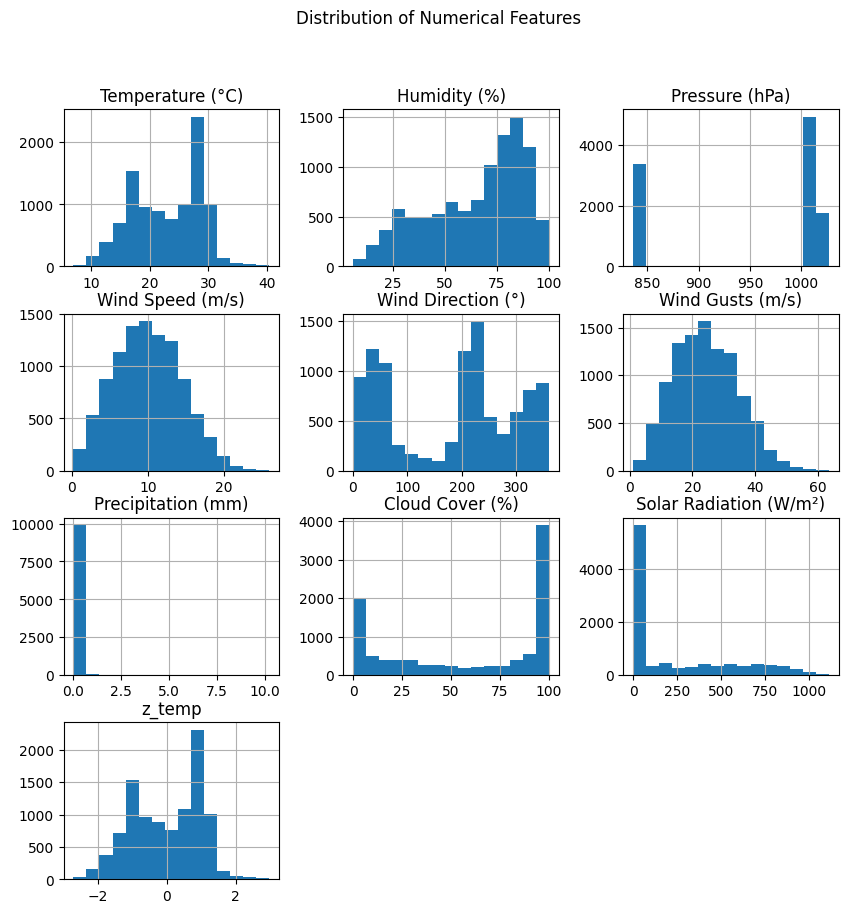

In [30]:
# Histogram of numerical features 
df_eda[numerical_cols].hist(figsize=(10, 10), bins=15)
plt.suptitle('Distribution of Numerical Features')
plt.show()

### Bivariate Analysis

In [33]:
# numerical columns (excluding Temperature) Closed in order not to exceed GitHub 2.0 MB file size
# uncomment it and run to see interesting relationship with temprature
"""
other_cols = ['Humidity (%)', 'Pressure (hPa)', 'Wind Speed (m/s)', 'Wind Direction (°)',
              'Wind Gusts (m/s)', 'Precipitation (mm)', 'Cloud Cover (%)', 'Solar Radiation (W/m²)']

# scatter plots to peruse relationship with temprature (Bivariate analysis)
fig, axes = plt.subplots(nrows=len(other_cols), ncols=1, figsize=(8, 20))

for i, col in enumerate(other_cols):
    sns.scatterplot(data=df_eda, x='Temperature (°C)', y=col, ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Relationship between Temperature and {col}')
    axes[i].set_xlabel('Temperature (°C)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()
"""

"\nother_cols = ['Humidity (%)', 'Pressure (hPa)', 'Wind Speed (m/s)', 'Wind Direction (°)',\n              'Wind Gusts (m/s)', 'Precipitation (mm)', 'Cloud Cover (%)', 'Solar Radiation (W/m²)']\n\n# scatter plots to peruse relationship with temprature (Bivariate analysis)\nfig, axes = plt.subplots(nrows=len(other_cols), ncols=1, figsize=(8, 20))\n\nfor i, col in enumerate(other_cols):\n    sns.scatterplot(data=df_eda, x='Temperature (°C)', y=col, ax=axes[i], alpha=0.5)\n    axes[i].set_title(f'Relationship between Temperature and {col}')\n    axes[i].set_xlabel('Temperature (°C)')\n    axes[i].set_ylabel(col)\n\nplt.tight_layout()\nplt.show()\n"

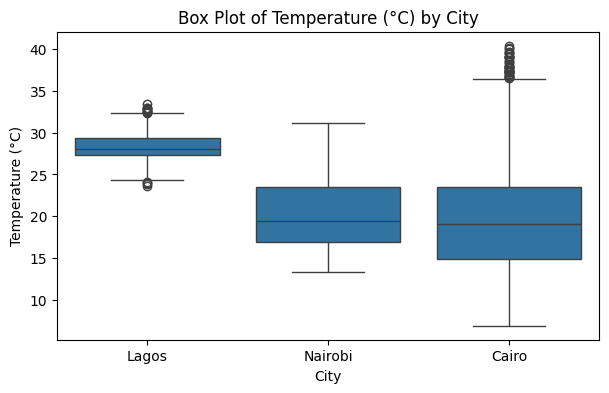

In [16]:
# Box plots of temprature by cities

plt.figure(figsize=(7, 4))
sns.boxplot(x=df_eda["City"], y=df_eda["Temperature (°C)"], data=df_eda)
plt.title(f'Box Plot of Temperature (°C) by City')
plt.show()

### Seasonal Trends

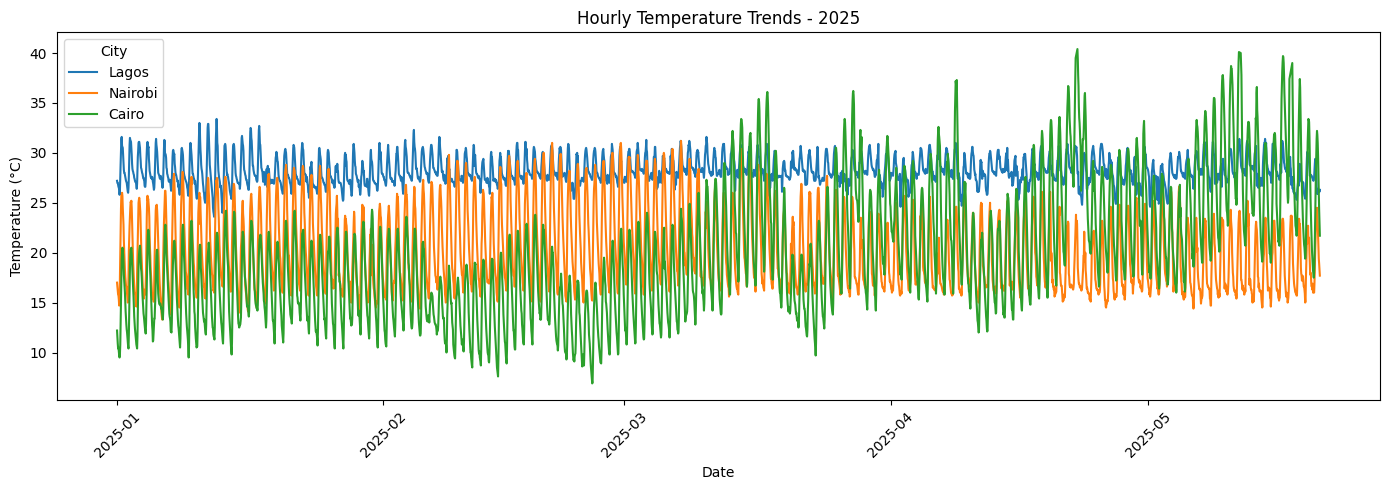

In [17]:
# Plot temperature trends for each city
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_eda, x='Datetime', y='Temperature (°C)', hue='City')
plt.title("Hourly Temperature Trends - 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Time series decomposition

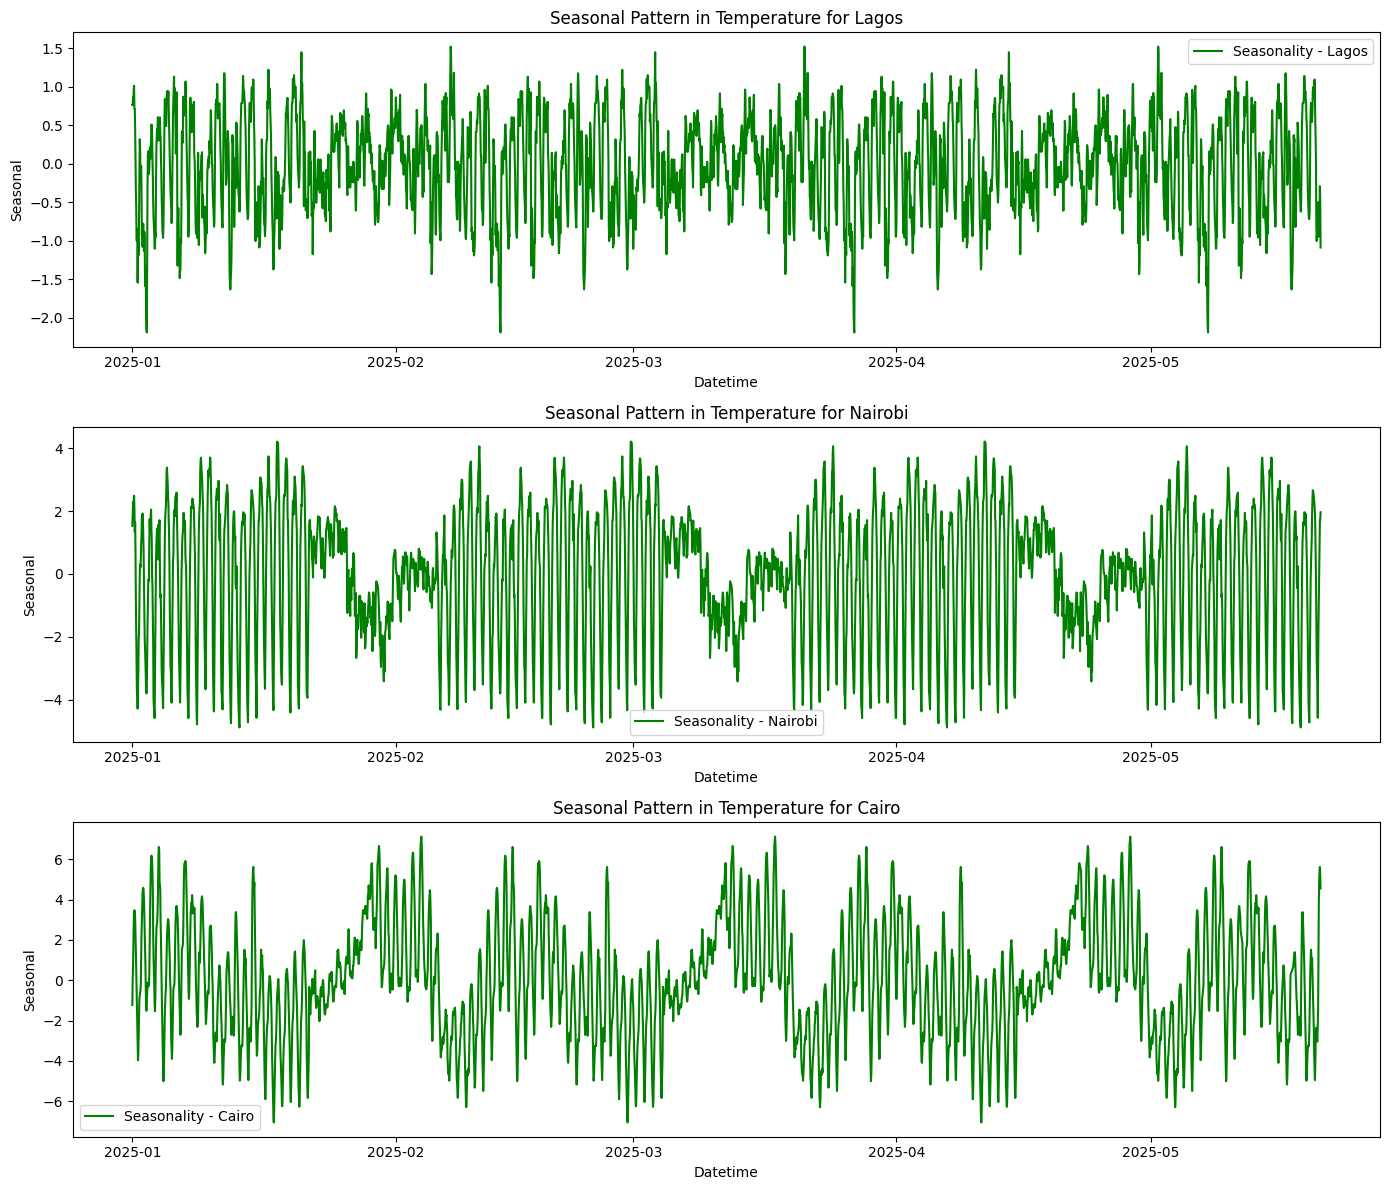

In [19]:


# Convert 'Datetime' column to datetime format
df_eda['Datetime'] = pd.to_datetime(df_eda['Datetime'])

# Loop through each city and perform seasonal decomposition
fig, axes = plt.subplots(nrows=len(df_eda['City'].unique()), ncols=1, figsize=(14, 12))

for i, city in enumerate(df_eda['City'].unique()):
    city_data = df_eda[df_eda['City'] == city].copy()
    
    # Perform seasonal decomposition
    decomposition = seasonal_decompose(city_data['Temperature (°C)'], model='additive', period=1000)
    city_data['Seasonal'] = decomposition.seasonal  # Keep seasonal values in the original DataFrame

    # Plot the seasonal component without setting Datetime as index
    sns.lineplot(data=city_data, x='Datetime', y='Seasonal', ax=axes[i], label=f'Seasonality - {city}', color='green')
    axes[i].set_title(f'Seasonal Pattern in Temperature for {city}')
    axes[i].legend()

plt.tight_layout()
plt.show()

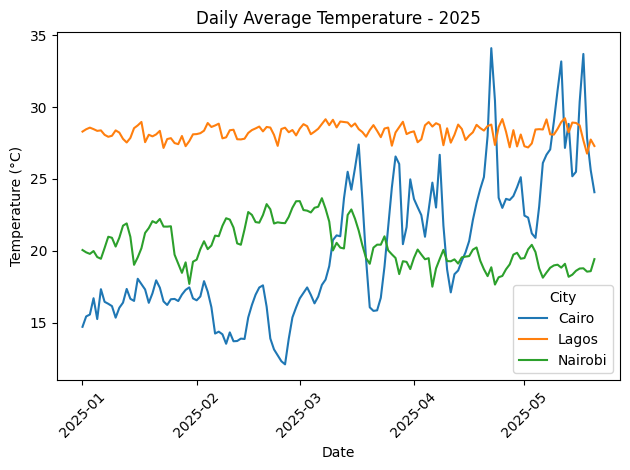

In [20]:
# daily averages
df['Date'] = df['Datetime'].dt.date
daily_avg = df.groupby(['Date', 'City'])['Temperature (°C)'].mean().reset_index()

sns.lineplot(data=daily_avg, x='Date', y='Temperature (°C)', hue='City')
plt.title("Daily Average Temperature - 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insights**
- Lagos maintained consistently warm temperatures throughout this year, making it the most stable climate among the cities analyzed.
- Cairo experienced a sharp contrast in temperature, with a notably cold period from January to March, followed by intense heat starting in April.
- Nairobi exhibited a mild and stable climate, staying comfortably cool, which suggests it might be the most suitable weather this year.


### Multivariate Analysis

### Correlation and Feature Insights

In [21]:
# Focus on numeric weather features
features = [
    'Temperature (°C)', 'Humidity (%)', 'Pressure (hPa)',
    'Wind Speed (m/s)', 'Wind Gusts (m/s)', 'Cloud Cover (%)', 'Solar Radiation (W/m²)'
]

In [28]:
# Pairplot for exploratory visualization (closed beacause of GitHub file size)
#sns.pairplot(df_eda[features + ['City']], hue='City')

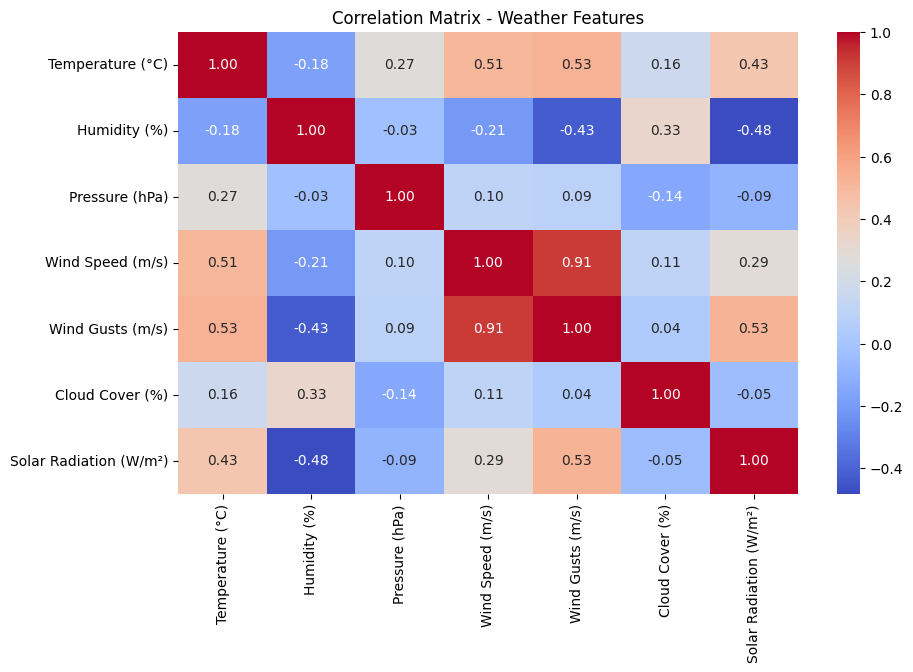

In [26]:
# Correlation matrix
plt.figure(figsize=(10, 6))
corr = df_eda[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Weather Features")
plt.show()

<Figure size 1000x700 with 0 Axes>

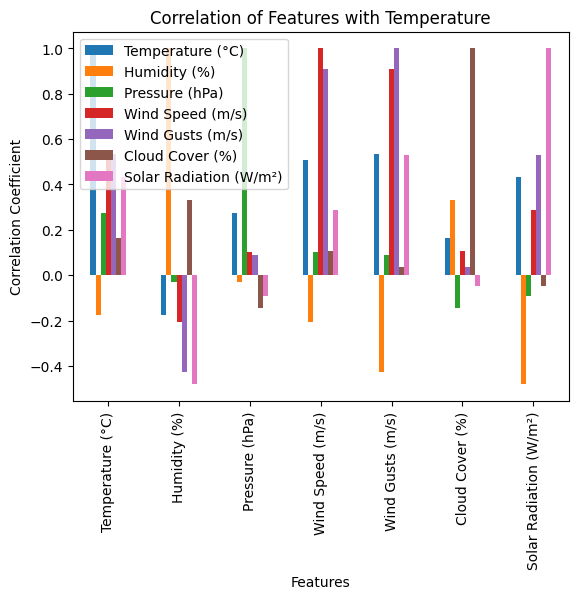

In [27]:
# Plot the correlation of each feature with temperature
plt.figure(figsize=(10, 7))
corr.plot(kind='bar')
plt.title("Correlation of Features with Temperature")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=90)
plt.show()


### Insights from EDA Correlation


- **Humidity and Cloud Cover** exhibit a negative correlation with temperature—greater cloud presence leads to reduced solar radiation, resulting in cooler conditions.
- **Solar Radiation** shows a strong positive correlation with temperature—higher sun exposure directly increases temperatures.
- **Atmospheric Pressure** demonstrates a weak/no correlation with temperature, indicating minimal direct influence on heat variations.
- **Wind Speed** has a slight negative correlation with temperature due to its cooling effect through evaporation and air mixing.
- **Other Insight** The EDA suggests **Nairobi** might be the most suitable weather this year out of the three studied cities.